In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

> ***personal note:***
>
> The `plot_function()` function visualizes a given function of a single variable over the interval $[a, b]$

In [2]:
import plotly.graph_objects as go

def _plot_function(f, bounds=(-16, 16), n=256):
  a, b = bounds
  xs = [a + i * (b - a) / n for i in range(n + 1)]
  ys = [f(x) for x in xs]
  fig = go.Figure(data=[go.Scatter(x=xs, y=ys, mode='lines')])
  fig.add_hline(y=0, line_color='black', line_width=1)
  fig.add_vline(x=0, line_color='black', line_width=1)
  fig.show()
  fig.show(renderer="png")
  return fig

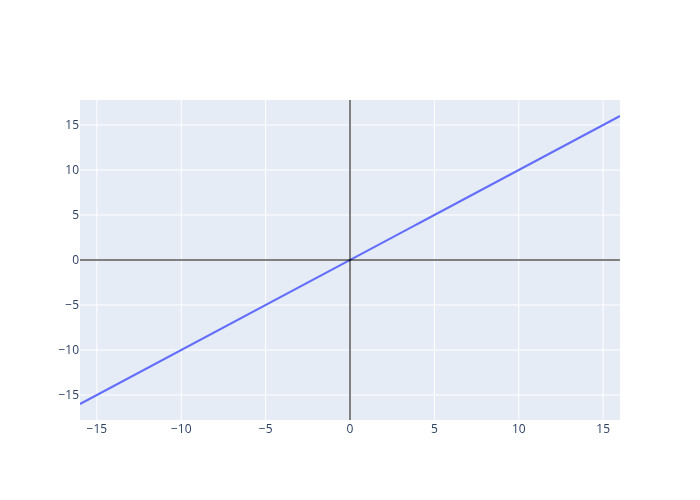

In [3]:
if __name__ == '__main__' and '__file__' not in globals():
  identity = lambda x: x
  _plot_function(identity)

> _**personal note:**_
>
> Numerical integration via **Simpson's rule** Approximates $\int_a^b f(x)\,dx$ by splitting $[a,b]$ into $n$ even panels and fitting a parabola through each consecutive triple of points.
>
> Each panel (3 points spaced by $h$) contributes:
>
> $$\int_{x_0}^{x_2} f(x)\,dx \approx \frac{h}{3}\left(f(x_0) + 4f(x_1) + f(x_2)\right)$$
>
> This method requires even $n$.

In [4]:
def __integrate(f, bound=(-16, 16), n = None):
  if n is None:
    n = 256
  a, b = bound
  result = 0
  xs = np.linspace(a, b, n+1)
  w = np.ones(n + 1); w[1:-1:2] = 4; w[2:-1:2] = 2
  h = (b - a) / n
  return (h / 3) * np.sum(w * f(xs))

In [5]:
if __name__ == '__main__' and '__file__' not in globals():
  print(__integrate(identity, (-2, 0))) # should print -2 (1/2 * base 2 * height -2)
  print(__integrate(identity, (0, 1))) # should print 0.5 (1/2 * base 1 * height 1)
  print(__integrate(identity, (0, math.sqrt(2)))) # should print 1 (1/2 * base sqrt2 * height sqrt2)

-2.0
0.5
1.0000000000000002


> _**personal note:**_
>
> moving on `scipy.integrate.quad()` will be used as an optimized substitute of `__integrate()`.

In [6]:
import scipy

def __integrate(f, bound=(-16, 16), n=None):
  a, b = bound
  val, err = scipy.integrate.quad(f, a, b)
  return val

In [7]:
if __name__ == '__main__' and '__file__' not in globals():
  print(__integrate(identity, (-2, 0))) # should print -2 (1/2 * base 2 * height -2)
  print(__integrate(identity, (0, 1))) # should print 0.5 (1/2 * base 1 * height 1)
  print(__integrate(identity, (0, math.sqrt(2)))) # should print 1 (1/2 * base sqrt2 * height sqrt2)

-2.0
0.5
1.0000000000000002


We say that a *random variable*, $x$, is distributed according to a particular PDF. Let $p(x)$ be a PDF for the random variable, $x$, over the interval $[a, b]$. This is a nonnegative function that satisfies

$$\int_a^b p(x)\,dx = 1. \tag{2.1}$$

That is, it satisfies the *axiom of total probability*. Note that this is *probability density*, not *probability*.

In [8]:
def _is_pdf(p, bound=(-16.0, 16.0)):
  a, b = bound
  # check total area = 1
  if (abs(__integrate(p, bound) - 1) < 0.001):
    # check nonnegativity
    xs = np.arange(a, b + 1, 0.125)
    if np.any(p(xs) < 0):
        return False
    return True
  return False

In [9]:
if __name__ == '__main__' and '__file__' not in globals():
  print(_is_pdf(identity, (-2.0, 0.0)))
  print(_is_pdf(identity, (0.0, 1.0)))
  print(_is_pdf(identity, (0.0, math.sqrt(2))))

False
False
True


Probability is given by the area under the density function. For example, the probability that $x$ lies between $c$ and $d$, $\Pr(c \leq x \leq d)$, is given by

$$\Pr(c \leq x \leq d) = \int_c^d p(x)\,dx. \tag{2.2}$$

In [10]:
def _probability(p, bound):
  return __integrate(p, bound)

In [11]:
if __name__ == '__main__' and '__file__' not in globals():
  identity = lambda x: x
  print(_probability(identity, (0, 2)))
  print(_probability(identity, (0, 1)))
  print(_probability(identity, (0, 0)))

2.0
0.5
0.0


> _**personal note:**_
>
> a *Gaussian distribution* is a PDF of the form
>
> $$p(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
>
> where $\mu$ is the mean and $\sigma$ the standard deviation.

In [12]:
def _gaussian(mean, stdev):
  def gaussian(x):
    return (1 / (stdev * np.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x - mean) / stdev) ** 2)
  return gaussian

We will also make use of the *cumulative distribution function (CDF)* on occasion, which is given by

$$P(x) = \Pr(x' \leq x) = \int_{-\infty}^{x} p(x')\,dx', \tag{2.3}$$

In [13]:
def _cdf(p):
  return lambda x: __integrate(p, (-16, x)) #-inf bound to -1024 for brevity

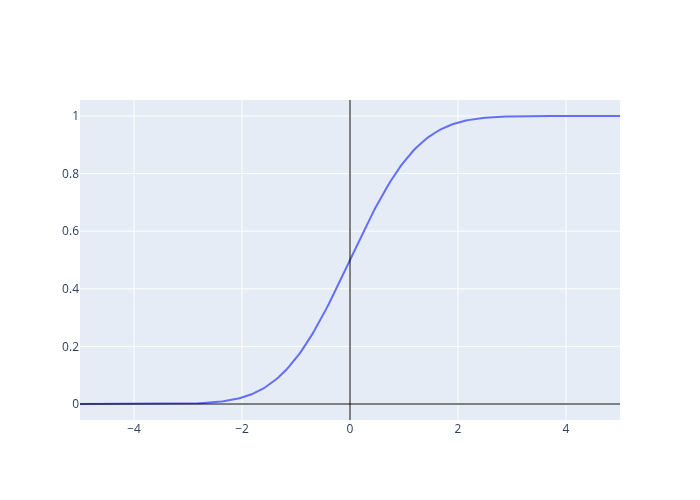

In [14]:
if __name__ == '__main__' and '__file__' not in globals():
  gaussian = _gaussian(0.0, 1.0)
  gaussian_cdf = _cdf(gaussian)
  _plot_function(gaussian_cdf, (-5, 5))

We can also introduce a conditioning variable to PDFs. Let $p(x|y)$ be a PDF over $x \in [a, b]$ conditioned on $y \in [r, s]$ such that

$$(\forall y) \quad \int_a^b p(x|y)\,dx = 1. \tag{2.4}$$

In [15]:
import inspect

def _is_pdf(p, a = -16, b = 16):
  # find argument count
  num_args = len(inspect.signature(p).parameters)

  # p is a function of 1 variable -> p(x)
  if (num_args == 1):
    # check total area = 1
    if (abs(_integrate(p, (a, b)) - 1) < 0.001):
      # check nonnegativity (iterate over all possible x)
      for i in np.arange(a, b + 1, 0.125):
        if p(i) < 0:
          return False
      return True
    return False
  # p is a function of 2 variable -> p(x|y)
  elif (num_args == 2):
    # define px
    def make_px(y):
      def px(x):
        return p(x, y)
      return px
    # iterate over all possible y
    for h in np.arange(a, b + 1, 0.125):
      px = make_px(h)
      # check total area = 1
      if (abs(_integrate(px, (a, b)) - 1) < 0.001):
        # check nonnegativity (iterate over all possible x)
        for i in np.arange(a, b + 1, 0.125):
          if px(i) < 0:
            return False
      else:
        return False
    return True

We may also denote *joint probability densities* for $N$-dimensional continuous variables in our framework as $p(\mathbf{x})$, where $\mathbf{x} = (x_1, \dots, x_N)$ with $x_i \in [a_i, b_i]$. Note that we can also use the notation

$$p(x_1, x_2, \dots, x_N) \tag{2.5}$$

in place of $p(\mathbf{x})$.

In [16]:
if __name__ == '__main__' and '__file__' not in globals():
  identity = lambda x: x #for brevity lets just assume values are equally distributed

  x = np.array([identity, identity, identity])
  px = np.array([_gaussian(0.0, 1.0), _gaussian(1.0, 2.0), _gaussian(-2.0, 0.5)])

Sometimes we even mix and match the two and write

$$p(\mathbf{x}, \mathbf{y}) \tag{2.6}$$

for the joint density of $\mathbf{x}$ and $\mathbf{y}$.

In [17]:
if __name__ == '__main__' and '__file__' not in globals():
  x = np.array([identity, identity, identity])
  px = np.array([_gaussian(0.0, 1.0), _gaussian(1.0, 2.0), _gaussian(-2.0, 0.5)])

  y = np.array([identity, identity, identity])
  py = np.array([_gaussian(5.0, 2.5), _gaussian(-10.0, 1.2), _gaussian(0.0, 0.1)])

  xy = np.concatenate((x, y))
  pxy = np.concatenate((px, py))

> _**personal note:**_
>
> we shall differentiate $\mathbf{x}$/$\mathbf{y}$ (vectors) from $x$/$y$ by adding an underscrore afterwards 
>
>*(i.e. `_x` =  $x$, whilst `x` = $\mathbf{x}$)*

for the joint density of $\mathbf{x}$ and $\mathbf{y}$. In the $N$-dimensional case, the axiom of total probability requires

$$\int_{\mathbf{a}}^{\mathbf{b}} p(\mathbf{x})\,d\mathbf{x} = \int_{a_N}^{b_N} \cdots \int_{a_2}^{b_2} \int_{a_1}^{b_1} p(x_1, x_2, \dots, x_N)\,dx_1\,dx_2 \cdots dx_N = 1, \tag{2.7}$$

where $\mathbf{a} = (a_1, a_2, \dots, a_N)$ and $\mathbf{b} = (b_1, b_2, \dots, b_N)$. In what follows, we will sometimes simplify notation by leaving out the integration limits, $\mathbf{a}$ and $\mathbf{b}$.

In [18]:
# note: this is exponentially expensive (O(n^n)) but works as a proof of concept
def _integrate(f, bounds=None, n = 256):
  if bounds is None:
    n_args = len(inspect.signature(f).parameters)
    bounds = [(-16.0, 16.0)] * n_args
  if len(bounds) == 1:
    return __integrate(f, bounds[0], n)
  else:
    def inner(x):
      return _integrate(lambda *rest: f(x, *rest), bounds[1:])
    return __integrate(inner, bounds[0], n)
  
def _is_nonnegative(f, bounds, params = []):
  if len(bounds) == 0:
    if f(*params) < 0.0:
      return False
    return True
  else:
    a, b = bounds[0]
    for i in np.arange(a, b + 1, 0.125):
      if not _is_nonnegative(f, bounds[1:], params + [i]):
        return False
    return True
  
def _is_pdf(f, bounds=None):
  if bounds is None:
    n_args = len(inspect.signature(f).parameters)
    bounds = [(-16.0, 16.0)] * n_args
  if _is_nonnegative(f, bounds):
    if abs(_integrate(f, bounds) - 1) < 0.001:
      return True
  return False

In [19]:
if __name__ == '__main__' and '__file__' not in globals():
  gaussian = _gaussian(0.0, 1.0)
  print(_integrate(gaussian))
  print(_is_pdf(gaussian))

1.0000000000000002
True


> _**personal note:**_
>
> moving on `scipy.integrate.nquad()` will be used as an optimized substitute of `_integrate()`.

In [29]:
def _integrate(f, bounds=None, n=None):
  if bounds is None:
    n_args = len(inspect.signature(f).parameters)
    bounds = [(-16.0, 16.0)] * n_args
  val, err = scipy.integrate.nquad(f, bounds)
  return val

In [30]:
if __name__ == '__main__' and '__file__' not in globals():
  gaussian = _gaussian(0.0, 1.0)
  print(_integrate(gaussian))
  print(_is_pdf(gaussian))

1.0000000000000002
True


<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>

1.0000000000000002
True


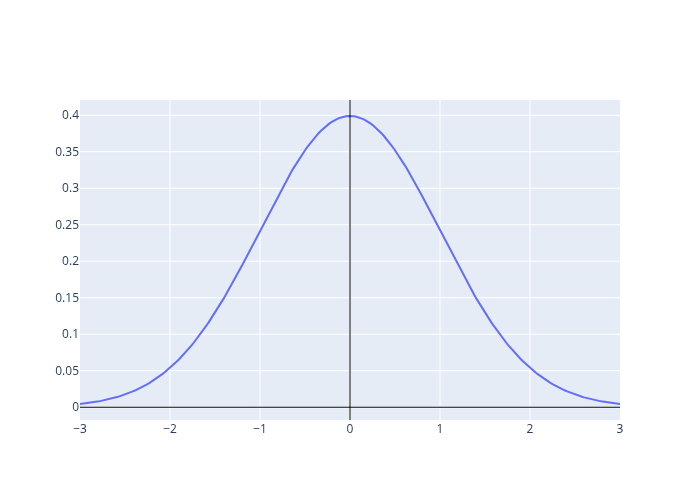

In [31]:
if __name__ == '__main__' and '__file__' not in globals():
  std_normal = _gaussian(0.0, 1.0)
  print(_integrate(std_normal, [(-16, 16)]))
  print(_is_pdf(std_normal))
  _plot_function(std_normal, (-3, 3))